In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import tensorflow as tf
import os
np.random.seed(42)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
datosMLP = pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/24paso/consumption/24pasos_mlp_consumption.csv')

datosMLP['date'] = pd.to_datetime(datosMLP['Unnamed: 0'])
datosMLP = datosMLP.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 11
datosMLP = datosMLP.iloc[corte:]

# Se establece la columna date como index
datosMLP.set_index('date', inplace=True)

datosMLP.head()

,Originales,Predichos
date,,
2017-11-25 01:30:00,-1.353240,-1.196666
2017-11-25 01:40:00,-1.345607,-1.216479
2017-11-25 01:50:00,-1.349847,-1.233016
2017-11-25 02:00:00,-1.400737,-1.248242
2017-11-25 02:10:00,-1.449082,-1.260602


In [4]:
datosLSTM = pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/24paso/consumption/24pasos_lstm_consumption.csv')

datosLSTM['date'] = pd.to_datetime(datosLSTM['Unnamed: 0'])
datosLSTM = datosLSTM.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 11
datosLSTM = datosLSTM.iloc[corte:]

# Se establece la columna date como index
datosLSTM.set_index('date', inplace=True)

datosLSTM.head()

,Originales,Predichos
date,,
2017-11-25 01:30:00,-1.353240,-1.282557
2017-11-25 01:40:00,-1.345607,-1.290783
2017-11-25 01:50:00,-1.349847,-1.300838
2017-11-25 02:00:00,-1.400737,-1.307360
2017-11-25 02:10:00,-1.449082,-1.315436


In [5]:
datosGRU= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/24paso/consumption/24pasos_gru_consumption.csv')

datosGRU['date'] = pd.to_datetime(datosGRU['Unnamed: 0'])
datosGRU = datosGRU.drop(columns=['Unnamed: 0'])

# Valor de la ventana contando el punto 0, se eliminan para comparación justa con Transformer
corte = 11
datosGRU = datosGRU.iloc[corte:]

# Se establece la columna date como index
datosGRU.set_index('date', inplace=True)

datosGRU.head()

,Originales,Predichos
date,,
2017-11-25 01:30:00,-1.353240,-1.336301
2017-11-25 01:40:00,-1.345607,-1.371741
2017-11-25 01:50:00,-1.349847,-1.387988
2017-11-25 02:00:00,-1.400737,-1.414091
2017-11-25 02:10:00,-1.449082,-1.419628


In [6]:
datosCross= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/24paso/consumption/crossformerConsumption.csv')

datosCross['date'] = pd.to_datetime(datosCross['Unnamed: 0'])
datosCross = datosCross.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosCross.set_index('date', inplace=True)

datosCross.head()

,Originales,Predichos
date,,
2017-11-25 01:30:00,-1.353240,-1.270602
2017-11-25 01:40:00,-1.345607,-1.298394
2017-11-25 01:50:00,-1.349847,-1.326305
2017-11-25 02:00:00,-1.400737,-1.352366
2017-11-25 02:10:00,-1.449083,-1.379984


In [7]:
datosI= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/24paso/consumption/itransformerConsumption.csv')

datosI['date'] = pd.to_datetime(datosI['Unnamed: 0'])
datosI = datosI.drop(columns=['Unnamed: 0'])


# Se establece la columna date como index
datosI.set_index('date', inplace=True)

datosI.head()

,Originales,Predichos
date,,
2017-11-25 01:30:00,-1.353240,-1.290887
2017-11-25 01:40:00,-1.345607,-1.330180
2017-11-25 01:50:00,-1.349847,-1.328700
2017-11-25 02:00:00,-1.400737,-1.337106
2017-11-25 02:10:00,-1.449083,-1.332529


In [8]:
datosTFT= pd.read_csv('/content/drive/MyDrive/Graficos tesis Nuevos/data/errores/NARMAX/24paso/consumption/tftConsumption.csv')

datosTFT['date'] = pd.to_datetime(datosTFT['Unnamed: 0'])
datosTFT = datosTFT.drop(columns=['Unnamed: 0'])

corte = 5347 - 5190 - 20
datosTFT = datosTFT.iloc[corte:]

# Se establece la columna date como index
datosTFT.set_index('date', inplace=True)

datosTFT.head()

,Originales,Predichos
date,,
2017-11-25 01:30:00,-1.353240,-1.083530
2017-11-25 01:40:00,-1.345607,-1.091609
2017-11-25 01:50:00,-1.349847,-1.101324
2017-11-25 02:00:00,-1.400737,-1.110805
2017-11-25 02:10:00,-1.449082,-1.117417


## MLP ##

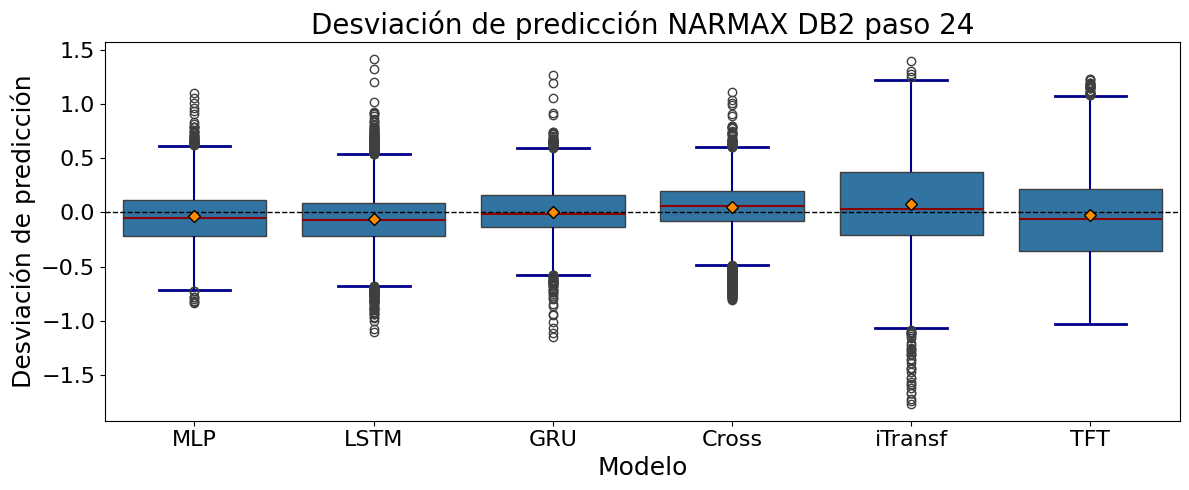

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Función para calcular las desviaciones
def calcular_desviacion(df, nombre_modelo):
    desviacion = df['Originales'] - df['Predichos']
    return pd.DataFrame({'Desviacion': desviacion, 'Modelo': nombre_modelo})

# Lista de modelos y sus datos
dataframes = [datosMLP, datosLSTM, datosGRU, datosCross, datosI, datosTFT]
nombres_modelos = ['MLP', 'LSTM', 'GRU', 'Cross', 'iTransf', 'TFT']

# Calcular todas las desviaciones
todas_las_desviaciones = [calcular_desviacion(df, nombre_modelo) for df, nombre_modelo in zip(dataframes, nombres_modelos)]

# Combinar todos los DataFrames en uno solo
df_grafico = pd.concat(todas_las_desviaciones, ignore_index=True)

# Crear los gráficos de caja
plt.figure(figsize=(12, 5))
sns.boxplot(x='Modelo', y='Desviacion', data=df_grafico, showmeans=True,
            meanprops={"marker":"D", "markerfacecolor":"darkorange", "markeredgecolor":"black"},
            medianprops={"color": "darkred", "linewidth": 1.5},
            whiskerprops=dict(color="darkblue", linewidth=1.5),
            capprops=dict(color="darkblue", linewidth=2))

# Línea horizontal en y=0
plt.axhline(0, linestyle= "--",color='black', linewidth=1.0)


plt.title('Desviación de predicción NARMAX DB2 paso 24', fontsize=20)
plt.ylabel('Desviación de predicción', fontsize=18)
plt.xlabel('Modelo', fontsize=18)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

#Por la naturaleza del gráfico, no se incluye leyenda

# Ajustar la presentación
plt.tight_layout()
plt.show()


# Graficos Q-Q

In [10]:
rMLP = pd.DataFrame(datosMLP['Originales'] - datosMLP['Predichos'], columns=['MLP'])
rLSTM = pd.DataFrame(datosLSTM['Originales'] - datosLSTM['Predichos'], columns=['LSTM'])
rGRU = pd.DataFrame(datosGRU['Originales'] - datosGRU['Predichos'], columns=['GRU'])
rCross = pd.DataFrame(datosCross['Originales'] - datosCross['Predichos'], columns=['Crossformer'])
rI = pd.DataFrame(datosI['Originales'] - datosI['Predichos'], columns=['iTransformer'])
rTFT = pd.DataFrame(datosTFT['Originales'] - datosTFT['Predichos'], columns=['TFT'])

final = rMLP.join(rLSTM, how='outer').join(rGRU, how='outer').join(rCross, how='outer').join(rI, how='outer').join(rTFT, how='outer')
final.head()





,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2017-11-25 01:30:00,-0.156574,-0.070683,-0.016939,-0.082638,-0.062353,-0.269710
2017-11-25 01:40:00,-0.129127,-0.054824,0.026134,-0.047213,-0.015427,-0.253998
2017-11-25 01:50:00,-0.116831,-0.049010,0.038141,-0.023543,-0.021148,-0.248524
2017-11-25 02:00:00,-0.152495,-0.093377,0.013354,-0.048371,-0.063631,-0.289933
2017-11-25 02:10:00,-0.188480,-0.133646,-0.029454,-0.069099,-0.116553,-0.331666


In [11]:
finalTotal = final.isna().sum()
print(finalTotal)
final = final.dropna()

MLP             0
LSTM            0
GRU             0
Crossformer     0
iTransformer    0
TFT             0
dtype: int64


In [12]:
final = final.sample(frac=0.10, random_state=42)
final.head()

,MLP,LSTM,GRU,Crossformer,iTransformer,TFT
date,,,,,,
2017-12-13 12:10:00,0.028248,0.001052,-0.254673,0.168926,0.797978,0.078598
2017-12-28 07:40:00,-0.040943,-0.162697,0.124977,-0.149156,-0.294294,-0.376997
2017-12-15 10:10:00,-0.143507,0.125330,0.026915,0.190963,0.336111,0.069257
2017-12-26 20:00:00,-0.159555,-0.175402,-0.333409,-0.078860,0.171720,0.494609
2017-12-30 18:30:00,0.231212,-0.111081,0.035122,-0.103243,0.359130,0.624031


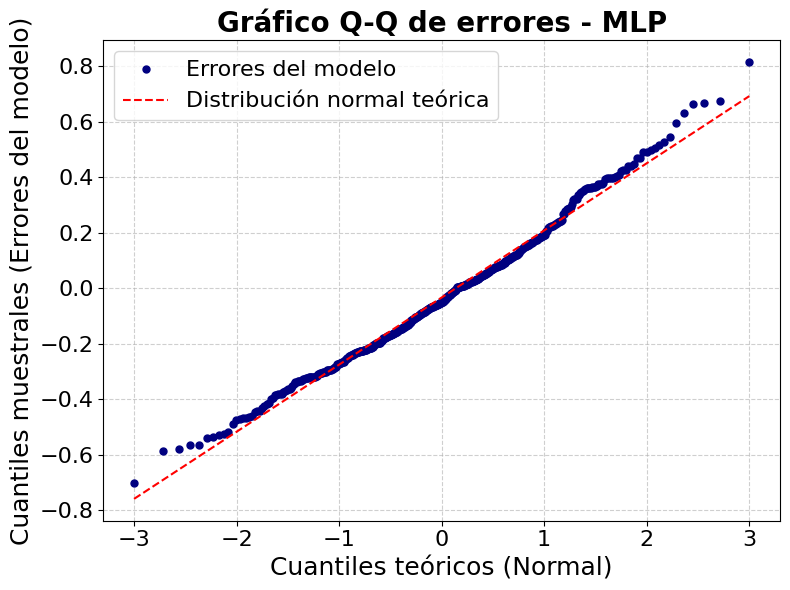

In [13]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["MLP"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - MLP", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


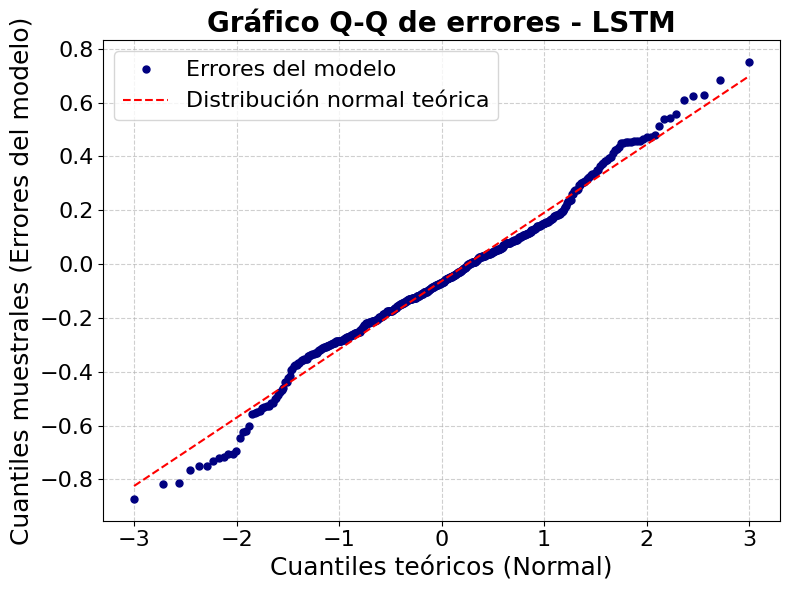

In [14]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["LSTM"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - LSTM", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


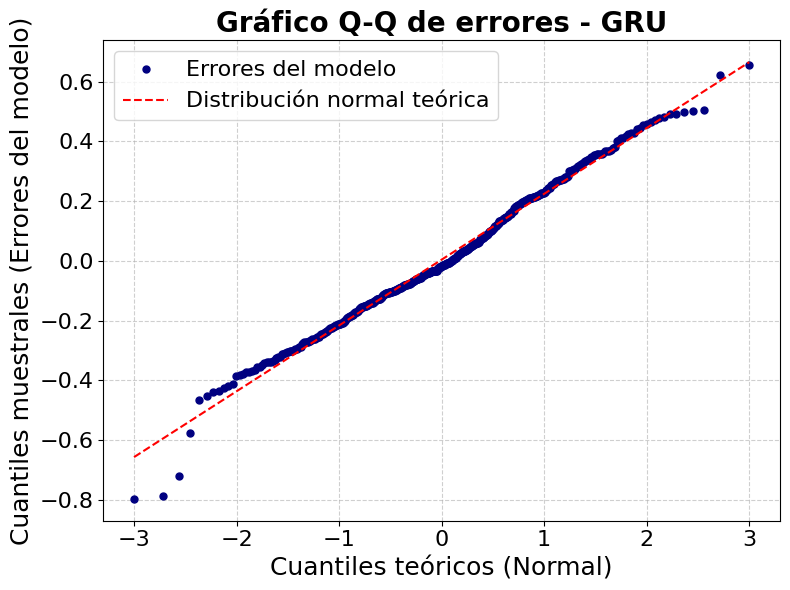

In [15]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["GRU"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - GRU", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


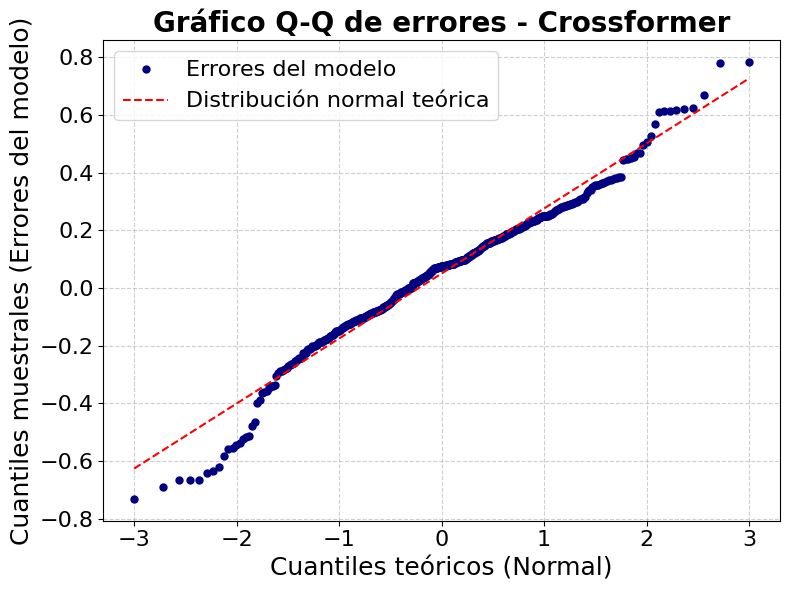

In [16]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["Crossformer"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - Crossformer", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


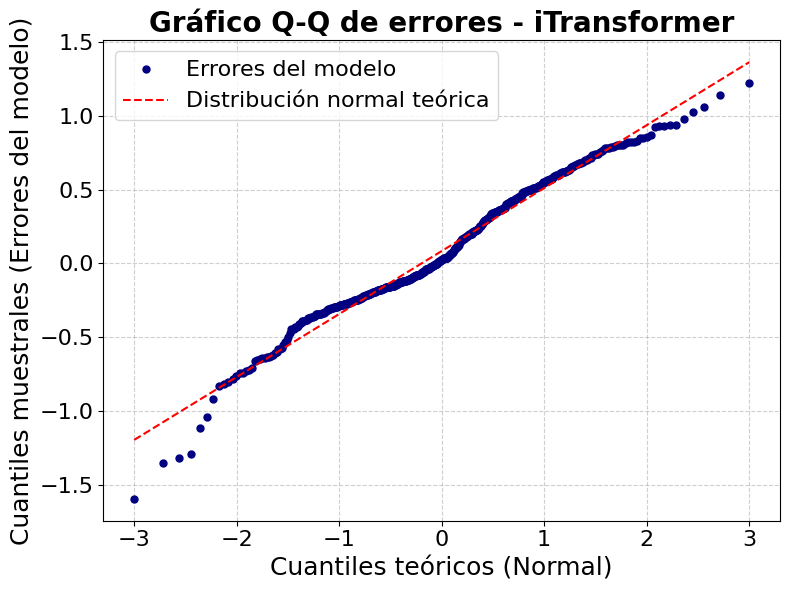

In [17]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["iTransformer"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - iTransformer", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


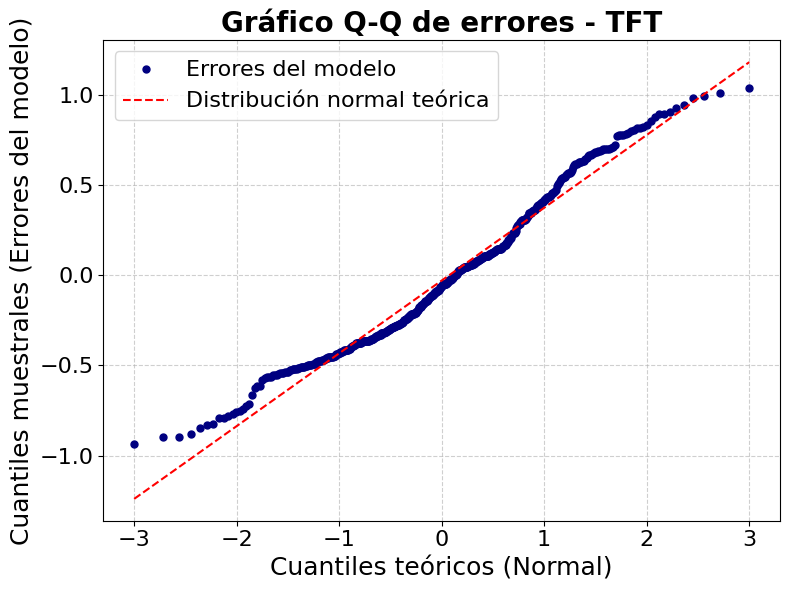

In [18]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(8, 6))


res = stats.probplot(final["TFT"], dist="norm", plot=plt)


points = plt.gca().lines[0]
line = plt.gca().lines[1]


points.set_marker('o')
points.set_color('navy')
points.set_markersize(5)
points.set_label("Errores del modelo")


line.set_color('red')
line.set_linestyle('--')
line.set_label("Distribución normal teórica")


plt.title("Gráfico Q-Q de errores - TFT", fontsize=20, fontweight='bold')
plt.xlabel("Cuantiles teóricos (Normal)", fontsize=18)
plt.ylabel("Cuantiles muestrales (Errores del modelo)", fontsize=18)


plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.grid(visible=True, linestyle="--", alpha=0.6)


plt.legend(fontsize=16, loc="best")

plt.tight_layout()
plt.show()


# Predicción

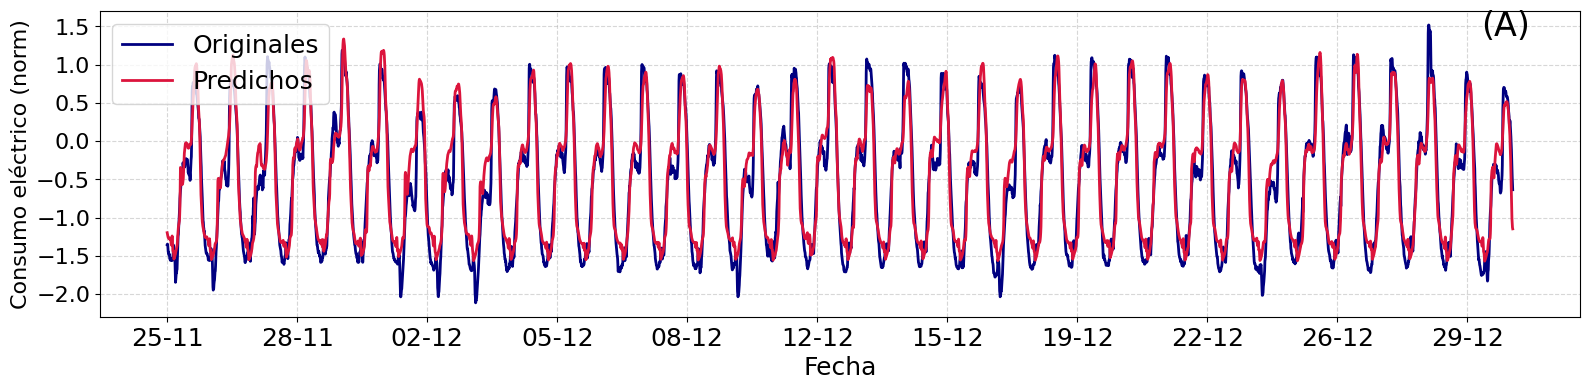

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


plt.figure(figsize=(16, 4))

df = datosMLP
plt.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')
plt.plot(df.index, df["Predichos"], color='crimson', linewidth=2,  label='Predichos')

espaciado = 500
ticks_x = df.index[::espaciado]
plt.xticks(ticks=ticks_x, labels=[ts.strftime("%d-%m") for ts in ticks_x], fontsize=18)


plt.yticks(fontsize=16)

plt.xlabel("Fecha", fontsize=18)
plt.ylabel("Consumo eléctrico (norm)", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

# Letra para marcar el subgráfico
plt.text(0.95, 0.95, '(A)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)

plt.legend(fontsize=18, loc="best")

plt.tight_layout()
plt.show()


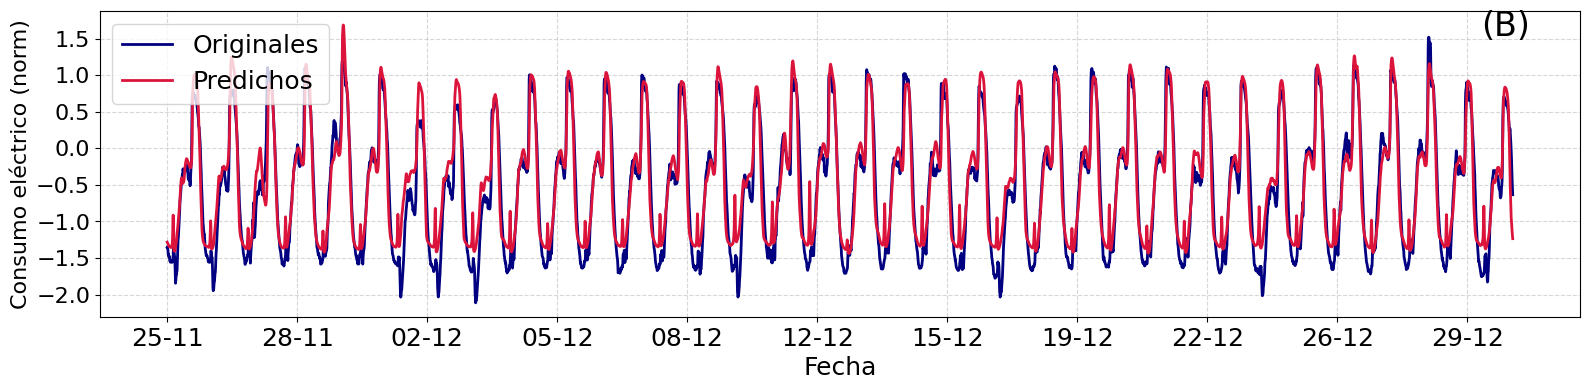

In [20]:

plt.figure(figsize=(16, 4))

df = datosLSTM
plt.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')
plt.plot(df.index, df["Predichos"], color='crimson', linewidth=2,  label='Predichos')

espaciado = 500
ticks_x = df.index[::espaciado]
plt.xticks(ticks=ticks_x, labels=[ts.strftime("%d-%m") for ts in ticks_x], fontsize=18)


plt.yticks(fontsize=16)

plt.xlabel("Fecha", fontsize=18)
plt.ylabel("Consumo eléctrico (norm)", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

# Letra para marcar el subgráfico
plt.text(0.95, 0.95, '(B)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)

plt.legend(fontsize=18, loc="best")

plt.tight_layout()
plt.show()

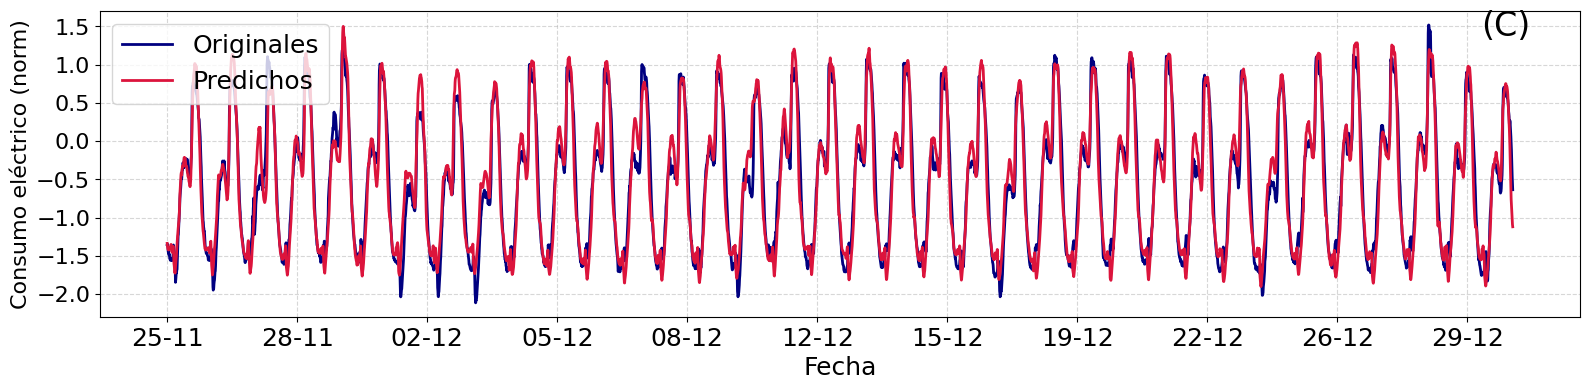

In [21]:

plt.figure(figsize=(16, 4))

df = datosGRU
plt.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')
plt.plot(df.index, df["Predichos"], color='crimson', linewidth=2,  label='Predichos')

espaciado = 500
ticks_x = df.index[::espaciado]
plt.xticks(ticks=ticks_x, labels=[ts.strftime("%d-%m") for ts in ticks_x], fontsize=18)


plt.yticks(fontsize=16)

plt.xlabel("Fecha", fontsize=18)
plt.ylabel("Consumo eléctrico (norm)", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

# Letra para marcar el subgráfico
plt.text(0.95, 0.95, '(C)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)

plt.legend(fontsize=18, loc="best")

plt.tight_layout()
plt.show()

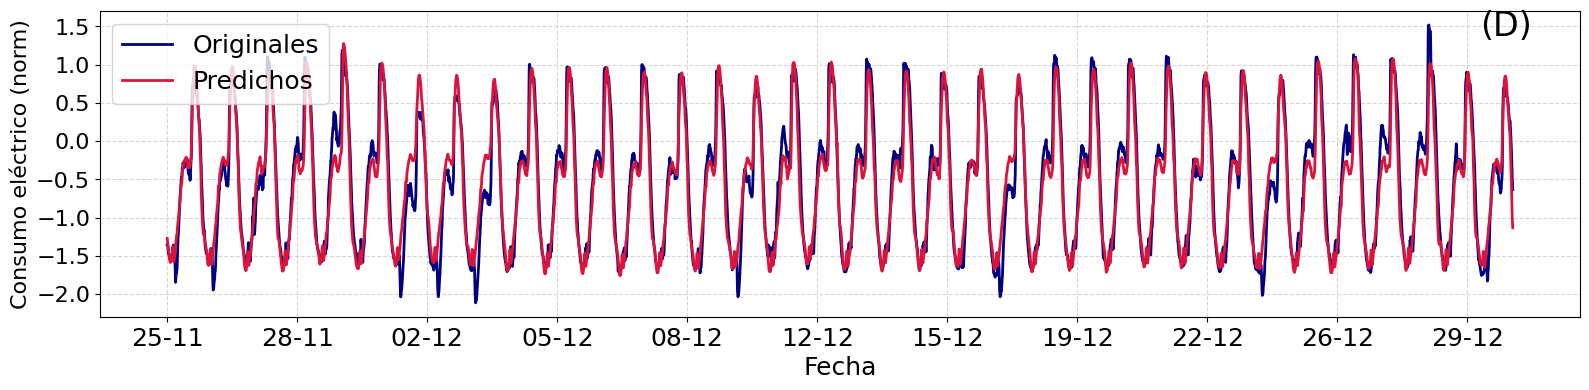

In [22]:

plt.figure(figsize=(16, 4))

df = datosCross
plt.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')
plt.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

espaciado = 500
ticks_x = df.index[::espaciado]
plt.xticks(ticks=ticks_x, labels=[ts.strftime("%d-%m") for ts in ticks_x], fontsize=18)


plt.yticks(fontsize=16)

plt.xlabel("Fecha", fontsize=18)
plt.ylabel("Consumo eléctrico (norm)", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

# Letra para marcar el subgráfico
plt.text(0.95, 0.95, '(D)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)

plt.legend(fontsize=18, loc="best")

plt.tight_layout()
plt.show()

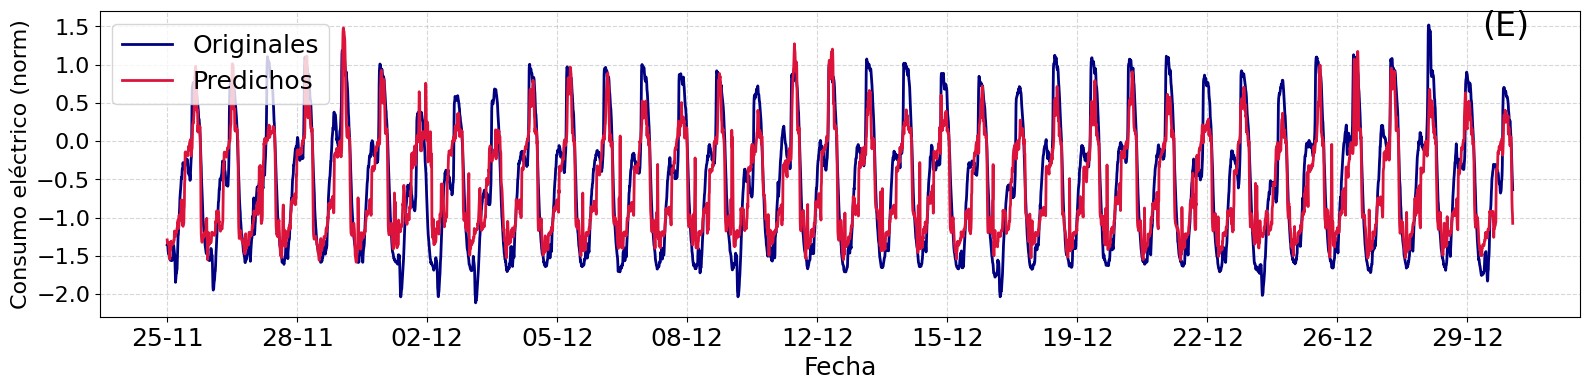

In [23]:

plt.figure(figsize=(16, 4))

df = datosI
plt.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')
plt.plot(df.index, df["Predichos"], color='crimson', linewidth=2, label='Predichos')

espaciado = 500
ticks_x = df.index[::espaciado]
plt.xticks(ticks=ticks_x, labels=[ts.strftime("%d-%m") for ts in ticks_x], fontsize=18)


plt.yticks(fontsize=16)

plt.xlabel("Fecha", fontsize=18)
plt.ylabel("Consumo eléctrico (norm)", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

# Letra para marcar el subgráfico
plt.text(0.95, 0.95, '(E)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)

plt.legend(fontsize=18, loc="best")

plt.tight_layout()
plt.show()

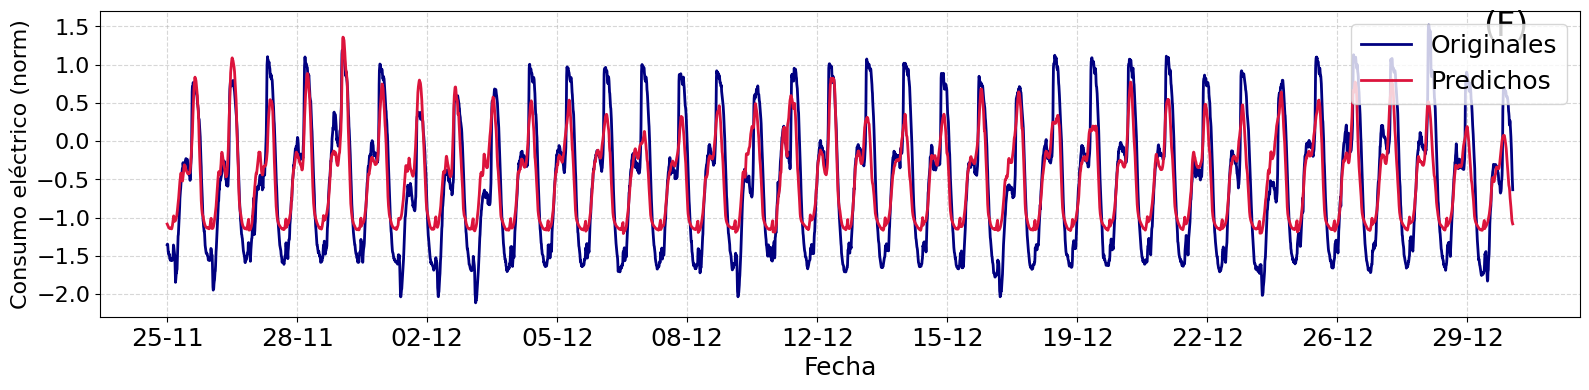

In [24]:

plt.figure(figsize=(16, 4))

df = datosTFT
plt.plot(df.index, df["Originales"], color='navy', linewidth=2, label='Originales')
plt.plot(df.index, df["Predichos"], color='crimson', linewidth=2,  label='Predichos')

espaciado = 500
ticks_x = df.index[::espaciado]
plt.xticks(ticks=ticks_x, labels=[ts.strftime("%d-%m") for ts in ticks_x], fontsize=18)


plt.yticks(fontsize=16)

plt.xlabel("Fecha", fontsize=18)
plt.ylabel("Consumo eléctrico (norm)", fontsize=16)

plt.grid(True, linestyle='--', alpha=0.5)

# Letra para marcar el subgráfico
plt.text(0.95, 0.95, '(F)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=24)

plt.legend(fontsize=18, loc="best")

plt.tight_layout()
plt.show()

# Métricas

In [25]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error, mean_absolute_error

def smape(y_true, y_pred):
    summ = np.abs(y_true) + np.abs(y_pred)
    smape_val = np.abs(y_pred - y_true) / summ * 2.0
    return np.mean(smape_val)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

def ia(y_true, y_pred):
    numerator = np.sum(np.abs(y_true - y_pred))
    denominator = np.sum(np.abs(y_true - np.mean(y_true)) + np.abs(y_pred - np.mean(y_true)))
    return 1 - (numerator / denominator)

In [26]:
#MLP
df = datosMLP

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.06315517277175747
RMSE: 0.2513069294145258
MAE: 0.2000497312947577
SMAPE: 0.4663541909537501
IA: 0.8590677555007431


In [27]:
#LSTM
df = datosLSTM

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.07591341351766859
RMSE: 0.2755238891959617
MAE: 0.21012929116708084
SMAPE: 0.4340293997363994
IA: 0.8473832798218333


In [28]:
#GRU
df = datosGRU

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.0548847057399734
RMSE: 0.23427485084825772
MAE: 0.1807729026619577
SMAPE: 0.4514938584534685
IA: 0.8768106743344232


In [29]:
#CROSS
df = datosCross

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.05736952235182691
RMSE: 0.23951935694600324
MAE: 0.18301102458725796
SMAPE: 0.4205913991519032
IA: 0.8675938593227077


In [30]:
#iTransf
df = datosI

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.17774930189254257
RMSE: 0.4216032517575529
MAE: 0.3357071446930609
SMAPE: 0.6699275216829133
IA: 0.7437245946318483


In [31]:
#TFT
df = datosTFT

mse = mean_squared_error(df["Originales"], df["Predichos"])


rmse_value = rmse(df["Originales"], df["Predichos"])

mae = mean_absolute_error(df["Originales"], df["Predichos"])

smape_value = smape(df["Originales"], df["Predichos"])

ia_value = ia(df["Originales"], df["Predichos"])


print(f'MSE: {mse}')
print(f'RMSE: {rmse_value}')
print(f'MAE: {mae}')
print(f'SMAPE: {smape_value}')
print(f'IA: {ia_value}')

MSE: 0.179156079309693
RMSE: 0.4232683301520361
MAE: 0.34464885915325116
SMAPE: 0.6496419246801417
IA: 0.7155349284568401


# Pruebas de significación

In [32]:
import scipy.stats as stats
from scipy.stats import kstest, norm


In [33]:
W, p = kstest(final["MLP"], norm.cdf, args=(0, 1))
print("MLP:", p)
W, p = kstest(final["LSTM"], norm.cdf, args=(0, 1))
print("LSTM:", p)
W, p = kstest(final["GRU"], norm.cdf, args=(0, 1))
print("GRU:", p)
W, p = kstest(final["Crossformer"], norm.cdf, args=(0, 1))
print("Cross:", p)
W, p = kstest(final["iTransformer"], norm.cdf, args=(0, 1))
print("iTransf:", p)
W, p = kstest(final["TFT"], norm.cdf, args=(0, 1))
print("TFT:", p)


MLP: 4.2529591801080156e-42
LSTM: 4.075446973145477e-43
GRU: 2.365567352102343e-50
Cross: 6.799094474878437e-51
iTransf: 3.391747353315466e-32
TFT: 1.2670970873606498e-27


In [34]:
stat, p_value = stats.friedmanchisquare(final["MLP"], final["LSTM"], final["GRU"], final["Crossformer"], final["iTransformer"], final["TFT"])
print(p_value)

5.092731016508706e-54


In [35]:
from statsmodels.stats.multitest import multipletests


# Realizamos comparaciones múltiples con Wilcoxon
comparisons = [
    ('MLP', 'LSTM'),
    ('MLP', 'GRU'),
    ('MLP', 'Crossformer'),
    ('MLP', 'iTransformer'),
    ('MLP', 'TFT'),
    ('LSTM', 'GRU'),
    ('LSTM', 'Crossformer'),
    ('LSTM', 'iTransformer'),
    ('LSTM', 'TFT'),
    ('GRU', 'Crossformer'),
    ('GRU', 'iTransformer'),
    ('GRU', 'TFT'),
    ('Crossformer', 'iTransformer'),
    ('Crossformer', 'TFT'),
    ('iTransformer', 'TFT')
]

p_values = []
for model1, model2 in comparisons:
    _, p_val = stats.wilcoxon(final[model1], final[model2])
    p_values.append(p_val)

# Aplicar ajuste de Bonferroni y Holm
bonferroni_corrected = multipletests(p_values, alpha=0.05, method='bonferroni')
holm_corrected = multipletests(p_values, alpha=0.05, method='holm')

# Crear un dataframe con los resultados
results_df = pd.DataFrame({
    'Comparación': [f'{model1} vs {model2}' for model1, model2 in comparisons],
    'p-value original': p_values,
    'Ajustado Bonferroni': bonferroni_corrected[1],
    'Ajustado Holm': holm_corrected[1]
})

# Redondear los valores para una mejor presentación
results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']] = results_df[['p-value original', 'Ajustado Bonferroni', 'Ajustado Holm']].round(5)

# Mostrar la tabla
results_df

,Comparación,p-value original,Ajustado Bonferroni,Ajustado Holm
0,MLP vs LSTM,0.01012,0.15174,0.04046
1,MLP vs GRU,0.00000,0.00002,0.00001
2,MLP vs Crossformer,0.00000,0.00000,0.00000
3,MLP vs iTransformer,0.00000,0.00000,0.00000
4,MLP vs TFT,0.12537,1.00000,0.37612
5,LSTM vs GRU,0.00000,0.00000,0.00000
6,LSTM vs Crossformer,0.00000,0.00000,0.00000
7,LSTM vs iTransformer,0.00000,0.00000,0.00000
8,LSTM vs TFT,0.36936,1.00000,0.73872
9,GRU vs Crossformer,0.00000,0.00000,0.00000
